In [22]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
df = pd.read_csv('/content/sample_data/food_delivery_orders.csv')
df.head()
df1 = pd.read_csv('/content/sample_data/food_delivery_customers.csv')
df1.head()

,customer_id,total_orders,average_order_value,average_delivery_distance_km
0,C001,52,784.24,7.77
1,C002,12,270.79,2.69
2,C003,37,722.89,7.80
3,C004,5,236.49,2.63
4,C005,9,205.59,3.95


In [37]:
def statistical_summary(csv_file):
    df = pd.read_csv(csv_file)

    # Required columns for statistical analysis
    numeric_columns = [
        "order_value",
        "delivery_distance_km"
    ]

    results = []

    for column in numeric_columns:
        data = df[column].dropna()

        mean = data.mean()
        median = data.median()
        std = data.std()
        skewness = data.skew()

        if skewness > 0.5:
            direction = "Right-skewed"
            interpretation = (
                f"Values are generally concentrated toward the lower side, "
                f"with some higher values creating a longer right tail."
            )

        elif skewness < -0.5:
            direction = "Left-skewed"
            interpretation = (
                f"Values are generally concentrated toward the higher side, "
                f"with some lower values creating a longer left tail."
            )

        else:
            direction = "Approximately symmetric"
            interpretation = (
                f"Values are fairly balanced around the center, with no "
                f"strong skewness."
            )

        results.append({
            "Column": column,
            "Mean": round(mean, 2),
            "Median": round(median, 2),
            "Standard Deviation": round(std, 2),
            "Skewness": round(skewness, 2),
            "Skewness Direction": direction,
            "Plain-English Interpretation": interpretation
        })

    return pd.DataFrame(results)

In [38]:
print("Order Value:")
print("Min:", df["order_value"].min())
print("Max:", df["order_value"].max())

print("\nDelivery Distance:")
print("Min:", df["delivery_distance_km"].min())
print("Max:", df["delivery_distance_km"].max())

print("\nRestaurant Rating:")
print("Min:", df["restaurant_rating"].min())
print("Max:", df["restaurant_rating"].max())

Order Value:
Min: 143.62
Max: 1363.98

Delivery Distance:
Min: 0.5
Max: 15.0

Restaurant Rating:
Min: 2.7
Max: 5.0


In [83]:
def validate_inputs(order_value, delivery_distance_km, restaurant_rating):

    try:
        order_value = float(order_value)
        delivery_distance_km = float(delivery_distance_km)
        restaurant_rating = float(restaurant_rating)

    except (ValueError, TypeError):
        print("Invalid input! Please enter numeric values.")
        return False

    # Validate order value
    if order_value < 143.62 or order_value > 1363.98:
        print("Invalid order value! It must be between 143.62 and 1363.98.")
        return False

    # Validate delivery distance
    if delivery_distance_km < 0.5 or delivery_distance_km > 15.0:
        print("Invalid delivery distance! It must be between 0.5 and 15.0 km.")
        return False

    # Validate restaurant rating
    if restaurant_rating < 1 or restaurant_rating > 5:
        print("Invalid restaurant rating! Rating must be between 1 and 5.")
        return False

    return True

In [84]:
x = df[['order_value', 'delivery_distance_km', 'restaurant_rating']]
y = df['cancelled']

In [85]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [86]:
rand_for = RandomForestClassifier(random_state=42)
rand_for.fit(x_train, y_train)

RandomForestClassifier(random_state=42)

In [67]:
def predict_cancellation_risk(order_value, delivery_distance_km, restaurant_rating):

    # Use validation function
    if not validate_inputs(order_value, delivery_distance_km, restaurant_rating):
        return

    input_data = [[
        float(order_value),
        float(delivery_distance_km),
        float(restaurant_rating)
    ]]

    prediction = rand_for.predict(input_data)[0]
    probability = rand_for.predict_proba(input_data)[0][1]

    if prediction == 1:
        print("Cancellation Prediction: Cancelled")
    else:
        print("Cancellation Prediction: Not Cancelled")

    print(f"Cancellation Probability: {probability:.2%}")

    if probability >= 0.5:
        print("Risk Level: High Cancellation Risk")
    else:
        print("Risk Level: Low Cancellation Risk")

In [87]:
predict_cancellation_risk(
    order_value=500,
    delivery_distance_km=7,
    restaurant_rating=3.5
)

Cancellation Prediction: Cancelled
Cancellation Probability: 66.00%
Risk Level: High Cancellation Risk


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [88]:
predict_cancellation_risk(
    order_value=500,
    delivery_distance_km=7,
    restaurant_rating=6
)

Invalid restaurant rating! Rating must be between 1 and 5.


Customer Count by Cluster:
Cluster 0: 10 customers
Cluster 1: 10 customers
Cluster 2: 10 customers

Cluster Centroids:

Cluster 0:
Total Orders: 21.80
Average Order Value: 425.81
Average Delivery Distance (km): 4.96

Cluster 1:
Total Orders: 41.60
Average Order Value: 733.21
Average Delivery Distance (km): 7.84

Cluster 2:
Total Orders: 7.10
Average Order Value: 223.91
Average Delivery Distance (km): 3.09


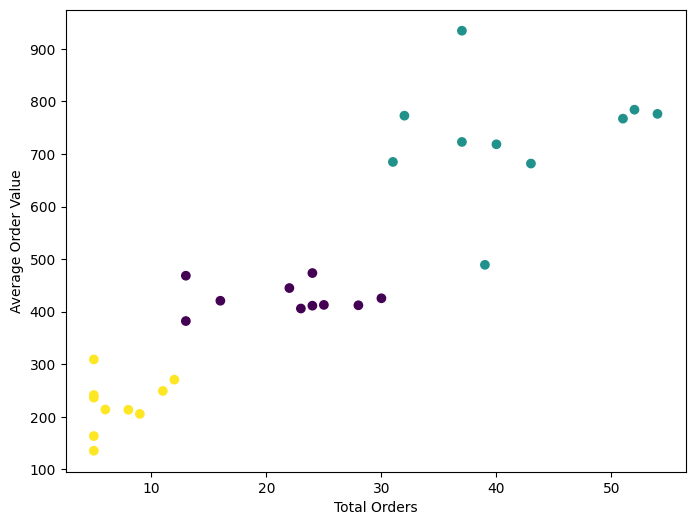

In [89]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# 1. Select customer behavior features
features = [
    'total_orders',
    'average_order_value',
    'average_delivery_distance_km'
]

X = df1[features]

# 2. Create StandardScaler
scaler = StandardScaler()

# 3. Scale the data
X_scaled = scaler.fit_transform(X)

# 4. Create K-Means model with k = 3
kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

# 5. Fit the K-Means model
kmeans.fit(X_scaled)

# 6. Get cluster labels
df1['cluster'] = kmeans.labels_

# 7. Count customers in each cluster
cluster_counts = df1['cluster'].value_counts().sort_index()

print("Customer Count by Cluster:")

for cluster, count in cluster_counts.items():
    print(f"Cluster {cluster}: {count} customers")

# 8. Convert centroids back to original units
centroids = scaler.inverse_transform(kmeans.cluster_centers_)

# 9. Display centroid values
print("\nCluster Centroids:")

for i, centroid in enumerate(centroids):
    print(f"\nCluster {i}:")
    print(f"Total Orders: {centroid[0]:.2f}")
    print(f"Average Order Value: {centroid[1]:.2f}")
    print(f"Average Delivery Distance (km): {centroid[2]:.2f}")

plt.figure(figsize=(8, 6))
plt.scatter(
    df1['total_orders'],
    df1['average_order_value'],
    c=df1['cluster'],
    cmap='viridis'
)
plt.xlabel('Total Orders')
plt.ylabel('Average Order Value')
plt.show()

In [90]:
def run_customer_segmentation():

    # Customer behavior features
    features = [
        'total_orders',
        'average_order_value',
        'average_delivery_distance_km'
    ]

    X = df1[features]

    # Standardize the data
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    # K-Means with k = 3
    kmeans = KMeans(
        n_clusters=3,
        random_state=42,
        n_init=10
    )

    # Fit the model
    kmeans.fit(X_scaled)

    # Get cluster labels
    df1['cluster'] = kmeans.labels_

    # Count customers in each cluster
    cluster_counts = df1['cluster'].value_counts().sort_index()

    print("\nCustomer Count by Cluster:")

    for cluster, count in cluster_counts.items():
        print(f"Cluster {cluster}: {count} customers")

    # Convert centroids back to original units
    centroids = scaler.inverse_transform(kmeans.cluster_centers_)

    print("\nCluster Centroids:")

    for i, centroid in enumerate(centroids):
        print(f"\nCluster {i}:")
        print(f"Total Orders: {centroid[0]:.2f}")
        print(f"Average Order Value: {centroid[1]:.2f}")
        print(f"Average Delivery Distance (km): {centroid[2]:.2f}")


def main_menu():

    while True:

        print("\n================================")
        print(" Food Delivery Intelligence Tool")
        print("================================")
        print("1. View Statistical Summary")
        print("2. Predict Cancellation Risk for a New Order")
        print("3. Run Customer Segmentation")
        print("4. Exit")

        choice = input("\nEnter your choice: ")

        # Option 1: Statistical Summary
        if choice == "1":

            print("\n--- Statistical Summary ---")

            result = statistical_summary(
                '/content/sample_data/food_delivery_orders.csv'
            )

            print(result)

        # Option 2: Cancellation Risk Prediction
        elif choice == "2":

            print("\n--- Cancellation Risk Prediction ---")

            order_value = input("Enter order value: ")
            delivery_distance = input("Enter delivery distance (km): ")
            restaurant_rating = input("Enter restaurant rating (1-5): ")

            predict_cancellation_risk(
                order_value,
                delivery_distance,
                restaurant_rating
            )

        # Option 3: Customer Segmentation
        elif choice == "3":

            print("\n--- Customer Segmentation ---")

            run_customer_segmentation()

        # Option 4: Exit
        elif choice == "4":

            print("\nExiting Food Delivery Customer Intelligence System. Goodbye!")
            break

        # Invalid choice
        else:

            print("\nInvalid choice. Please select an option from 1 to 4.")

In [91]:
main_menu()


 Food Delivery Intelligence Tool
1. View Statistical Summary
2. Predict Cancellation Risk for a New Order
3. Run Customer Segmentation
4. Exit

Enter your choice: 1

--- Statistical Summary ---
                 Column    Mean  Median  Standard Deviation  Skewness  \
0           order_value  444.97  412.38              195.91      1.29   
1  delivery_distance_km    4.76    4.04                3.23      1.22   

  Skewness Direction                       Plain-English Interpretation  
0       Right-skewed  Values are generally concentrated toward the l...  
1       Right-skewed  Values are generally concentrated toward the l...  

 Food Delivery Intelligence Tool
1. View Statistical Summary
2. Predict Cancellation Risk for a New Order
3. Run Customer Segmentation
4. Exit

Enter your choice: 4

Exiting Food Delivery Customer Intelligence System. Goodbye!
